In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
from torchvision import models, transforms

In [2]:
DATA_ROOT = Path("./two_class_cifar")
OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Data root:", DATA_ROOT.resolve())
print("Output dir:", OUTPUT_DIR.resolve())

Data root: /home/amyliu/Desktop/GR/two_class_cifar
Output dir: /home/amyliu/Desktop/GR/outputs


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [4]:
image_paths = []
labels = []

for label_dir in ["cat", "dog"]:
    folder = DATA_ROOT / label_dir
    for img_path in sorted(folder.glob("*.png")):
        image_paths.append(img_path)
        labels.append(label_dir)

print("Total images:", len(image_paths))
print("First 5 paths:")
for p in image_paths[:5]:
    print(p)

Total images: 40
First 5 paths:
two_class_cifar/cat/cat_000.png
two_class_cifar/cat/cat_001.png
two_class_cifar/cat/cat_002.png
two_class_cifar/cat/cat_003.png
two_class_cifar/cat/cat_004.png


In [5]:
resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# 去掉最后的全连接层，只保留到 avgpool 后
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /home/amyliu/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 86.7MB/s]


Sequential(
  (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)


In [6]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [7]:
resnet_embeddings = []
metadata_rows = []

with torch.no_grad():
    for img_path, label in tqdm(list(zip(image_paths, labels)), total=len(image_paths)):
        image = Image.open(img_path).convert("RGB")
        img_tensor = transform(image).unsqueeze(0).to(device)  # shape: (1, 3, 224, 224)

        feat = feature_extractor(img_tensor)   # shape: (1, 2048, 1, 1)
        feat = feat.view(feat.size(0), -1)     # shape: (1, 2048)
        feat = feat.squeeze(0).cpu().numpy()   # shape: (2048,)

        resnet_embeddings.append(feat)
        metadata_rows.append({
            "filename": img_path.name,
            "label": label,
            "path": str(img_path)
        })

resnet_embeddings = np.array(resnet_embeddings)
metadata_df = pd.DataFrame(metadata_rows)

print("Embedding shape:", resnet_embeddings.shape)
print(metadata_df.head())

100%|██████████| 40/40 [00:00<00:00, 79.34it/s]

Embedding shape: (40, 2048)
      filename label                             path
0  cat_000.png   cat  two_class_cifar/cat/cat_000.png
1  cat_001.png   cat  two_class_cifar/cat/cat_001.png
2  cat_002.png   cat  two_class_cifar/cat/cat_002.png
3  cat_003.png   cat  two_class_cifar/cat/cat_003.png
4  cat_004.png   cat  two_class_cifar/cat/cat_004.png


In [8]:
np.save(OUTPUT_DIR / "resnet_embeddings_cat_dog.npy", resnet_embeddings)
metadata_df.to_csv(OUTPUT_DIR / "resnet_metadata_cat_dog.csv", index=False)

print("Saved:", OUTPUT_DIR / "resnet_embeddings_cat_dog.npy")
print("Saved:", OUTPUT_DIR / "resnet_metadata_cat_dog.csv")

Saved: outputs/resnet_embeddings_cat_dog.npy
Saved: outputs/resnet_metadata_cat_dog.csv


In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.metrics.pairwise import cosine_similarity
from scipy.stats import gaussian_kde

OUTPUT_DIR = Path("./outputs")
FIG_DIR = OUTPUT_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

embeddings = np.load(OUTPUT_DIR / "resnet_embeddings_cat_dog.npy")
meta = pd.read_csv(OUTPUT_DIR / "resnet_metadata_cat_dog.csv")

print("embeddings shape:", embeddings.shape)
print(meta.head())
print(meta["label"].value_counts())

embeddings shape: (40, 2048)
      filename label                             path
0  cat_000.png   cat  two_class_cifar/cat/cat_000.png
1  cat_001.png   cat  two_class_cifar/cat/cat_001.png
2  cat_002.png   cat  two_class_cifar/cat/cat_002.png
3  cat_003.png   cat  two_class_cifar/cat/cat_003.png
4  cat_004.png   cat  two_class_cifar/cat/cat_004.png
label
cat    20
dog    20
Name: count, dtype: int64


In [10]:
sim_matrix = cosine_similarity(embeddings)

print("similarity matrix shape:", sim_matrix.shape)
print(sim_matrix[:5, :5])

similarity matrix shape: (40, 40)
[[1.0000001  0.6815445  0.49185753 0.6584618  0.6521417 ]
 [0.6815445  1.0000005  0.5060936  0.5990363  0.66485983]
 [0.49185753 0.5060936  1.0000001  0.44968003 0.34444714]
 [0.6584618  0.5990363  0.44968003 1.0000002  0.6547596 ]
 [0.6521417  0.66485983 0.34444714 0.6547596  0.9999999 ]]


In [11]:
n = len(meta)

all_sims = []
same_label_sims = []
cross_label_sims = []

for i in range(n):
    for j in range(i + 1, n):
        sim = sim_matrix[i, j]
        label_i = meta.loc[i, "label"]
        label_j = meta.loc[j, "label"]

        all_sims.append(sim)

        if label_i == label_j:
            same_label_sims.append(sim)
        else:
            cross_label_sims.append(sim)

print("Total pairs:", len(all_sims))
print("Same-label pairs:", len(same_label_sims))
print("Cross-label pairs:", len(cross_label_sims))

Total pairs: 780
Same-label pairs: 380
Cross-label pairs: 400


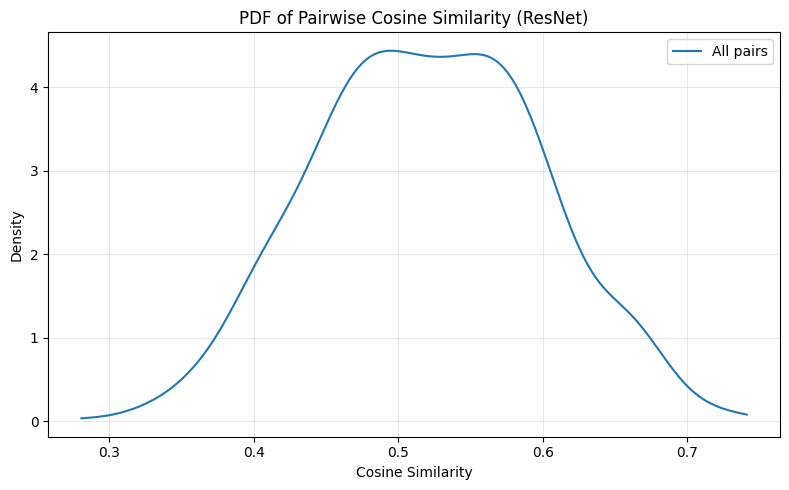

In [12]:
all_sims = np.array(all_sims)

x_grid = np.linspace(all_sims.min(), all_sims.max(), 500)
kde = gaussian_kde(all_sims)
pdf = kde(x_grid)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, pdf, label="All pairs")
plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("PDF of Pairwise Cosine Similarity (ResNet)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "pdf_resnet_all_pairs.png", dpi=300)
plt.show()

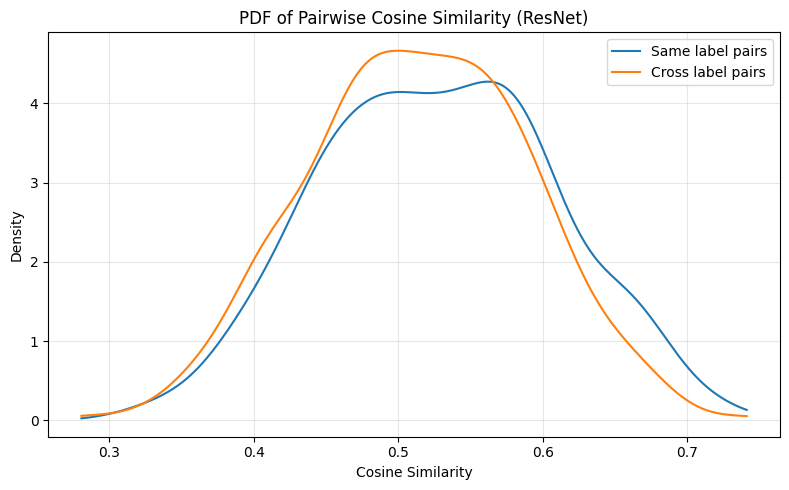

In [13]:
same_label_sims = np.array(same_label_sims)
cross_label_sims = np.array(cross_label_sims)

x_min = min(same_label_sims.min(), cross_label_sims.min())
x_max = max(same_label_sims.max(), cross_label_sims.max())
x_grid = np.linspace(x_min, x_max, 500)

kde_same = gaussian_kde(same_label_sims)
kde_cross = gaussian_kde(cross_label_sims)

pdf_same = kde_same(x_grid)
pdf_cross = kde_cross(x_grid)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, pdf_same, label="Same label pairs")
plt.plot(x_grid, pdf_cross, label="Cross label pairs")

plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("PDF of Pairwise Cosine Similarity (ResNet)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "pdf_resnet_same_vs_cross.png", dpi=300)
plt.show()

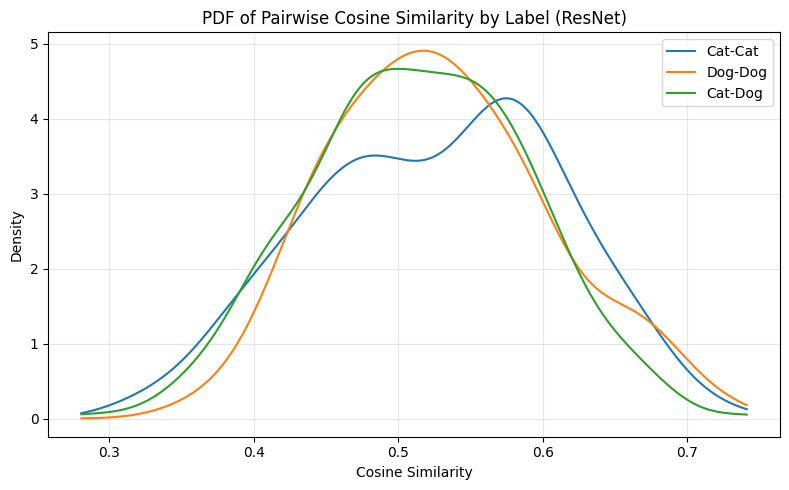

In [14]:
cat_cat_sims = []
dog_dog_sims = []
cat_dog_sims = []

for i in range(n):
    for j in range(i + 1, n):
        sim = sim_matrix[i, j]
        label_i = meta.loc[i, "label"]
        label_j = meta.loc[j, "label"]

        if label_i == "cat" and label_j == "cat":
            cat_cat_sims.append(sim)
        elif label_i == "dog" and label_j == "dog":
            dog_dog_sims.append(sim)
        else:
            cat_dog_sims.append(sim)

cat_cat_sims = np.array(cat_cat_sims)
dog_dog_sims = np.array(dog_dog_sims)
cat_dog_sims = np.array(cat_dog_sims)

x_min = min(cat_cat_sims.min(), dog_dog_sims.min(), cat_dog_sims.min())
x_max = max(cat_cat_sims.max(), dog_dog_sims.max(), cat_dog_sims.max())
x_grid = np.linspace(x_min, x_max, 500)

pdf_cat = gaussian_kde(cat_cat_sims)(x_grid)
pdf_dog = gaussian_kde(dog_dog_sims)(x_grid)
pdf_cross = gaussian_kde(cat_dog_sims)(x_grid)

plt.figure(figsize=(8, 5))
plt.plot(x_grid, pdf_cat, label="Cat-Cat")
plt.plot(x_grid, pdf_dog, label="Dog-Dog")
plt.plot(x_grid, pdf_cross, label="Cat-Dog")

plt.xlabel("Cosine Similarity")
plt.ylabel("Density")
plt.title("PDF of Pairwise Cosine Similarity by Label (ResNet)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.savefig(FIG_DIR / "pdf_resnet_cat_dog_cross.png", dpi=300)
plt.show()

In [15]:
pair_rows = []

for i in range(n):
    for j in range(i + 1, n):
        sim = sim_matrix[i, j]
        label_i = meta.loc[i, "label"]
        label_j = meta.loc[j, "label"]
        file_i = meta.loc[i, "filename"]
        file_j = meta.loc[j, "filename"]

        if label_i == label_j:
            pair_type = "same"
        else:
            pair_type = "cross"

        pair_rows.append({
            "idx1": i,
            "idx2": j,
            "file1": file_i,
            "file2": file_j,
            "label1": label_i,
            "label2": label_j,
            "pair_type": pair_type,
            "cosine_similarity": sim
        })

pair_df = pd.DataFrame(pair_rows)
pair_df.to_csv(OUTPUT_DIR / "resnet_pairwise_similarity.csv", index=False)

print(pair_df.head())
print("Saved:", OUTPUT_DIR / "resnet_pairwise_similarity.csv")

   idx1  idx2        file1        file2 label1 label2 pair_type  \
0     0     1  cat_000.png  cat_001.png    cat    cat      same   
1     0     2  cat_000.png  cat_002.png    cat    cat      same   
2     0     3  cat_000.png  cat_003.png    cat    cat      same   
3     0     4  cat_000.png  cat_004.png    cat    cat      same   
4     0     5  cat_000.png  cat_005.png    cat    cat      same   

   cosine_similarity  
0           0.681544  
1           0.491858  
2           0.658462  
3           0.652142  
4           0.592750  
Saved: outputs/resnet_pairwise_similarity.csv
